### 1、Import relevant library

In [10]:
# Using Hugging Face Datasets library
from datasets import load_dataset
import json

### 2、Download datasets

#### Datasets show
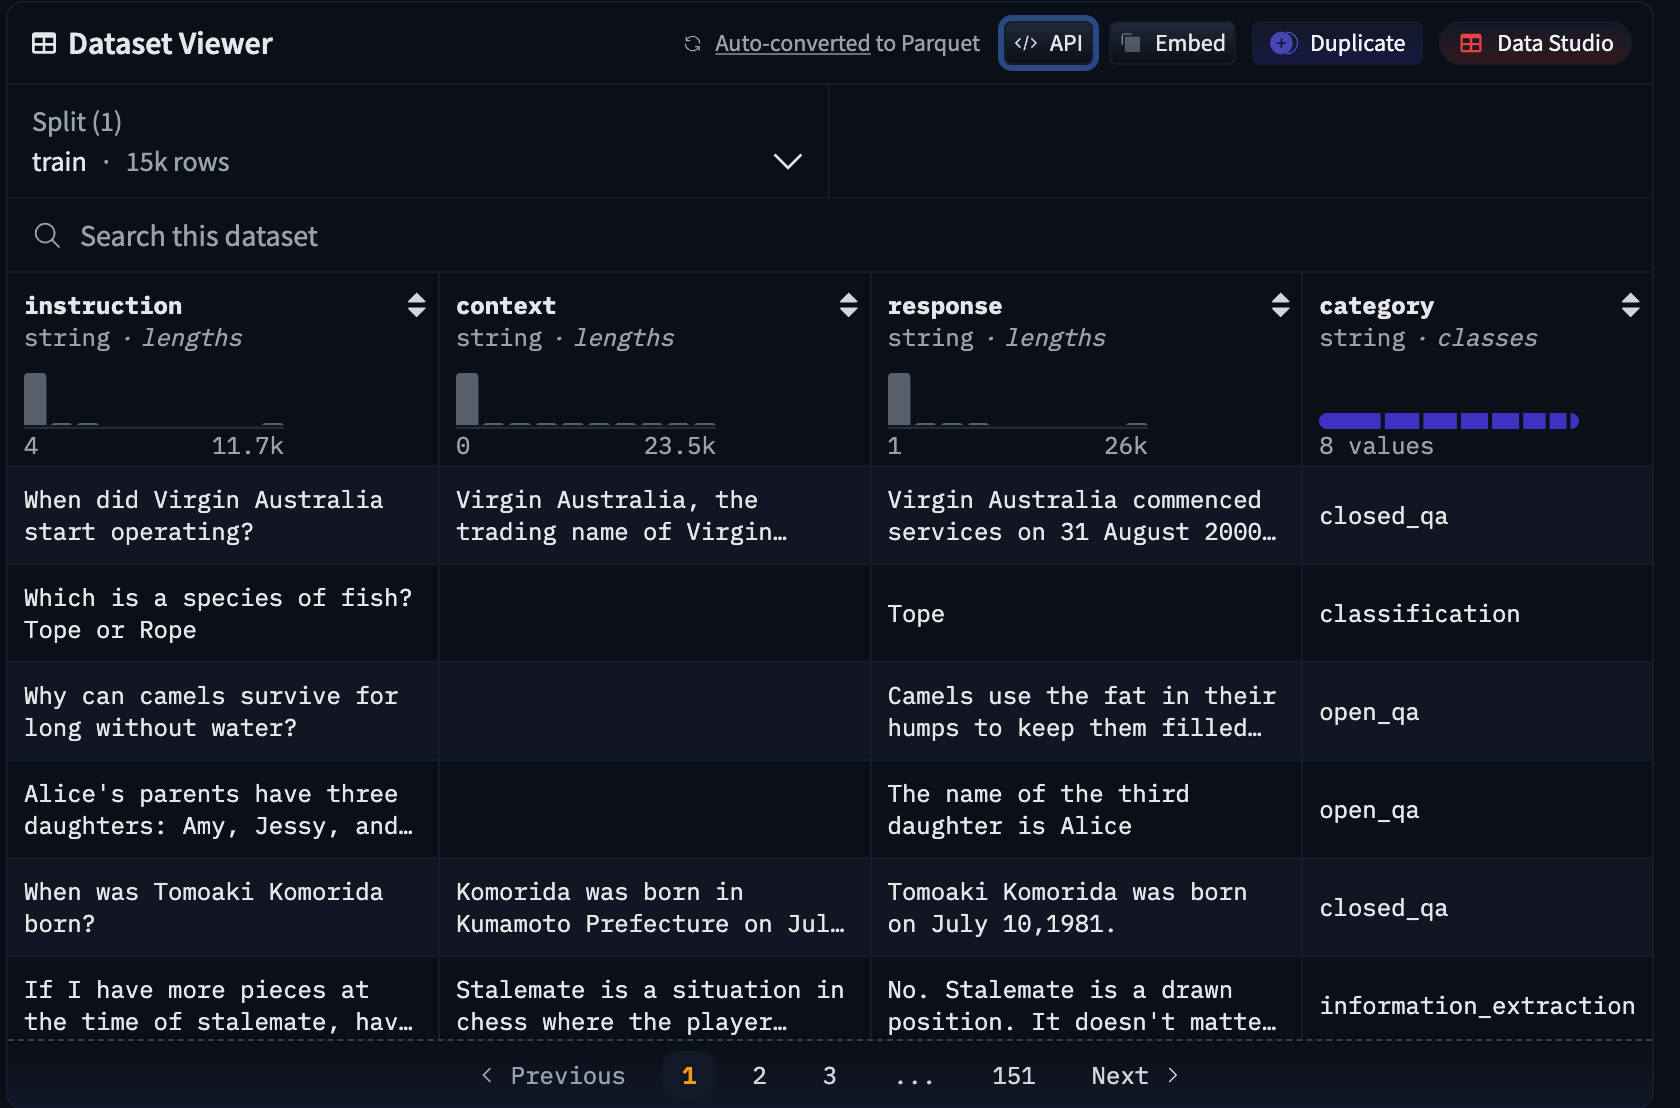

In [6]:
dataset = load_dataset("databricks/databricks-dolly-15k")
dataset

DatasetDict({
    train: Dataset({
        features: ['instruction', 'context', 'response', 'category'],
        num_rows: 15011
    })
})

### 3、Data format conversion

#### Note: Why do we need a strict `Prompt -> Response` format?

Transforming raw datasets (like Databricks Dolly-15k) into a standardized `Instruction -> Response` format is a critical preprocessing step for instruction fine-tuning. We do this for two fundamental reasons:

**1. Behavior Alignment (From Text Completion to Assistant)**
Base models like TinyLlama are pre-trained purely for *next-token prediction* on massive corpora. If fed raw, unformatted text, the model will simply attempt to continue the sequence based on statistical probability. By enforcing a strict structural boundary (e.g., separating the query and the target answer), we condition the model to transition from a "text-continuation engine" into an "instruction-following assistant."

**2. Loss Masking in PyTorch (The Engineering Necessity)**
During the training loop, we only want the model to learn how to generate the *Response*. We do not want to waste compute or update weights based on its ability to predict the user's *Prompt*. A uniform dataset format allows us to systematically apply **Loss Masking**. By tokenizing the prompt and setting its corresponding labels to `-100`, PyTorch's `CrossEntropyLoss` will completely ignore those tokens. This ensures that backpropagation and gradient updates are driven entirely by the quality of the generated response.

In [ ]:
def format_example(example):

    instruction = example["instruction"]
    context = example["context"]
    response = example["response"]
    # No need "category" for our tranining, it is more likely used to dataset slicing and purification.

    if context:

        prompt = (
            f"Instruction: {instruction}\n"
            f"Input: {context}\n"
            f"Response:"
        )
    # Some examples do not have context, we can simply omit the input part in the prompt.
    else:

        prompt = (
            f"Instruction: {instruction}\n"
            f"Response:"
        )

    return {
        "prompt": prompt,
        "response": response
    }

# Apply the formatting function efficiently across the entire dataset using Apache Arrow under the hood. 
dataset = dataset["train"].map(format_example)
dataset[0]

Map: 100%|██████████| 15011/15011 [00:00<00:00, 29026.06 examples/s]


{'instruction': 'When did Virgin Australia start operating?',
 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.",
 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.',
 'category': 'closed_qa',
 'prompt': "Instruction: When did Virgin Australia start operating?\nInput: Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced serv

### 4、Save file

In [9]:
with open("./data/train.jsonl", "w") as f:

    for item in dataset:

        line = json.dumps({
            "prompt": item["prompt"],
            "response": item["response"]
        })

        f.write(line + "\n")

print("Dataset saved to data/train.jsonl")

Dataset saved to data/train.jsonl
